<>:294: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:294: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/8p/gw16rjvx52140v_0wht9y82m0000gn/T/ipykernel_48655/2616205060.py:294: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[0].plot(X_arr, slope*X_arr + intercept, linestyle='--', color=c_col, alpha=0.6, label=f'Fit [$\lambda$ = {lambda_eff:.0f} cm]')


Found 75 ROOT files. Starting massive digitization...
 -> Simulated Cable: 20.0m RG-58 (-3.0 dB, Tr_cable=2.8 ns)
 -> Processing Run 1000 | Y=-145.0 mm, X=-200.0 mm | Sector=Middle Module (Comb 37, HDPE)
 -> Processing Run 1001 | Y=-145.0 mm, X=-400.0 mm | Sector=Middle Module (Comb 37, HDPE)
 -> Processing Run 1002 | Y=-145.0 mm, X=0.0 mm | Sector=Middle Module (Comb 37, HDPE)
 -> Processing Run 1003 | Y=-145.0 mm, X=200.0 mm | Sector=Middle Module (Comb 37, HDPE)
 -> Processing Run 1004 | Y=-145.0 mm, X=400.0 mm | Sector=Middle Module (Comb 37, HDPE)
 -> Processing Run 1005 | Y=-161.5 mm, X=-200.0 mm | Sector=Bottom Module (Bundle 37, Mylar)
 -> Processing Run 1006 | Y=-161.5 mm, X=-400.0 mm | Sector=Bottom Module (Bundle 37, Mylar)
 -> Processing Run 1007 | Y=-161.5 mm, X=0.0 mm | Sector=Bottom Module (Bundle 37, Mylar)
 -> Processing Run 1008 | Y=-161.5 mm, X=200.0 mm | Sector=Bottom Module (Bundle 37, Mylar)
 -> Processing Run 1009 | Y=-161.5 mm, X=400.0 mm | Sector=Bottom Module 

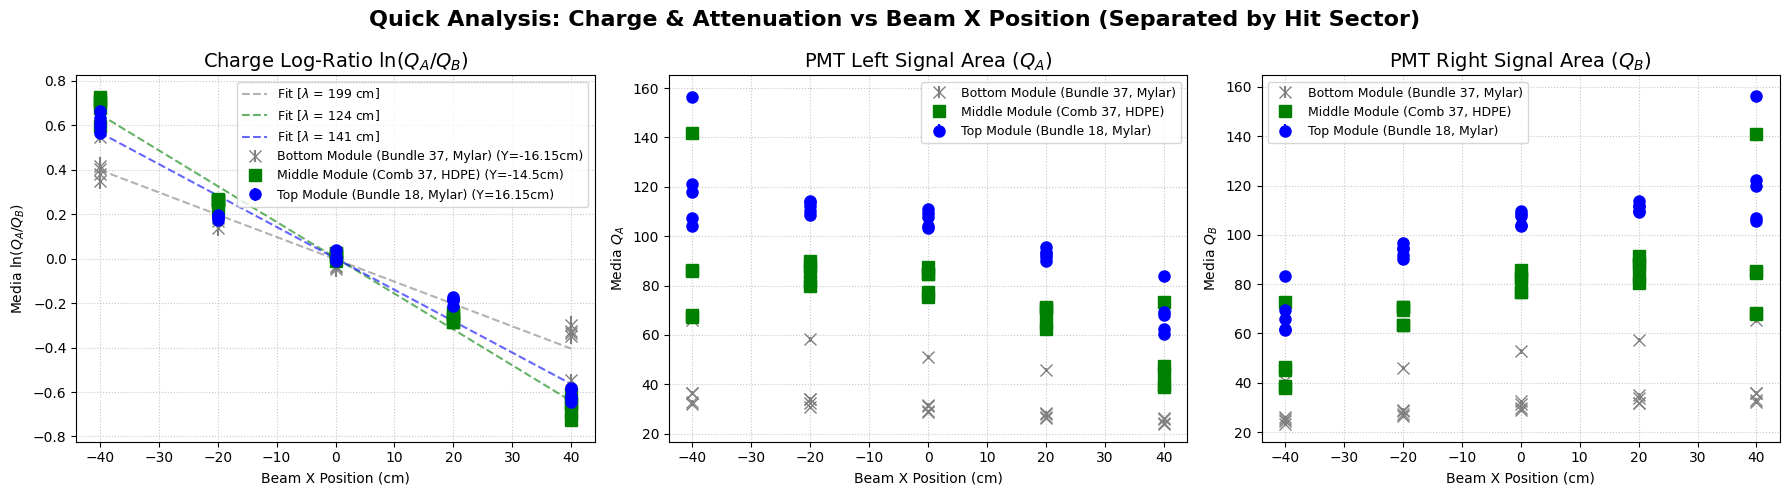


[OK] Run catalog saved to: /Users/benussi/Testbeam2026_WC/data/mc_runs_catalog.csv
[OK] Valid events summary saved to: /Users/benussi/Testbeam2026_WC/data/eventi_con_fotoni_summary.csv


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION PARAMETERS
# ============================================================
# Imposta l'ID del run che vuoi analizzare (es. 1000 per il primo file). Lascia None per analizzarli tutti.
RUN_SEL = None

MAX_DEBUG_PLOTS = 0  # <--- SET TO 3 TO SEE THE FIRST 3 WAVEFORMS

# --- Parametri Analisi "Al Volo" ---
PLOT_ATTENUATION = True # Calcola e mostra i plot ln(Q_A/Q_B) e le cariche alla fine

# ============================================================
# DIGITIZER, PMT & CABLE PARAMETERS
# ============================================================
SAMPLE_RATE_GS = 1.0       
DT_NS = 1.0 / SAMPLE_RATE_GS
RECORD_LENGTH = 1024       
ADC_BITS = 12              
V_PP_MV = 1000.0           
BASELINE_ADC = 3800        
NOISE_RMS_ADC = 3.5        

# PMT Properties
G = 1.0e6            
R = 50.0             
e_charge = 1.602e-19 
tr_pmt = 0.6         

# RG-58 Cable Properties
CABLE_LENGTH_M = 20.0
# RG-58 Attenuation: ~15 dB / 100m @ 100 MHz
ATTENUATION_DB = (15.0 / 100.0) * CABLE_LENGTH_M
TRANSMISSION_FACTOR = 10.0 ** (-ATTENUATION_DB / 20.0) 

# Cable Dispersion & Total Rise Time
tr_cable = 0.14 * CABLE_LENGTH_M 
tr_total = np.sqrt(tr_pmt**2 + tr_cable**2) 
sigma_total = tr_total / 2.22

# SPE Amplitude calculation
amp_SPE_mV_ideal = - (e_charge * G * R) / (sigma_total * 1e-9 * np.sqrt(2 * np.pi)) * 1e3 
amp_SPE_mV_attenuated = amp_SPE_mV_ideal * TRANSMISSION_FACTOR

def mv_to_adc(voltage_mv):
    lsb = V_PP_MV / (2**ADC_BITS)
    adc_float = BASELINE_ADC + (voltage_mv / lsb)
    adc_noisy = adc_float + np.random.normal(0, NOISE_RMS_ADC, len(adc_float))
    return np.clip(np.round(adc_noisy), 0, (2**ADC_BITS)-1).astype(np.uint16)

def get_quantum_efficiency(wavelengths_nm):
    wl_points = np.array([180.0, 200.0, 250.0, 300.0, 400.0, 420.0, 450.0, 500.0, 550.0, 600.0, 650.0])
    qe_points = np.array([0.00,  0.12,  0.21,  0.25,  0.27,  0.26,  0.22,  0.12,  0.05,  0.01,  0.00])
    return np.interp(wavelengths_nm, wl_points, qe_points, left=0.0, right=0.0)

# ============================================================
# BATCH READING AND OUTPUT PREPARATION
# ============================================================
input_dir = "/Users/benussi/Testbeam2026_WC/data"
root_files = glob.glob(os.path.join(input_dir, "*.root"))

output_dir = "/Users/benussi/Testbeam2026_WC/data"
os.makedirs(output_dir, exist_ok=True)

if len(root_files) == 0:
    print(f"No .root files found in {input_dir}. Please check the path.")
    exit()

print(f"Found {len(root_files)} ROOT files. Starting massive digitization...")
print(f" -> Simulated Cable: {CABLE_LENGTH_M}m RG-58 (-{ATTENUATION_DB:.1f} dB, Tr_cable={tr_cable:.1f} ns)")

time_axis = np.arange(0, RECORD_LENGTH * DT_NS, DT_NS)
mock_catalog = []
events_summary = []
current_run_id = 1000 
debug_plots_saved = 0
quick_analysis_data = []

for file_path in sorted(root_files):
    
    if RUN_SEL is not None and current_run_id != RUN_SEL:
        current_run_id += 1
        continue

    basename = os.path.basename(file_path)
    
    # REGEX semplificata: cerca solo Y e X
    match = re.search(r'Y([+-]?\d+\.?\d*)_X([+-]?\d+\.?\d*)', basename, re.IGNORECASE)
    
    if match:
        y_val  = float(match.group(1))
        x_val  = float(match.group(2)) 
        y_cm   = y_val / 10.0
        x_cm   = x_val / 10.0
        
        # Mappatura del settore colpito e dei PMT associati
        if y_cm < -15.0: 
            mod_name = "Bottom Module (Bundle 37, Mylar)"
            ch_A, ch_B = 0, 1
        elif abs(y_cm) <= 15.0: 
            mod_name = "Middle Module (Comb 37, HDPE)"
            ch_A, ch_B = 2, 3
        else: 
            mod_name = "Top Module (Bundle 18, Mylar)"
            ch_A, ch_B = 4, 5
    else:
        print(f"Unrecognized file name format for {basename}. Skipping.")
        continue
        
    print(f" -> Processing Run {current_run_id} | Y={y_val} mm, X={x_val} mm | Sector={mod_name}")
    
    events_data_per_file = {}

    try:
        file = uproot.open(file_path)
        tree = file["Fotoni"]
        df = tree.arrays(["EventID", "Arrival_Time_ns", "PMT_ID", "E_Hit_eV"], library="pd")
    except Exception as e:
        print(f"    [!] ROOT tree reading error: {e}")
        events_summary.append({'File_Root': basename, 'Valid_Events_Min_1_Photon': "Read Error"})
        current_run_id += 1
        continue
        
    if df.empty:
        print("    [!] No photons recorded in this run.")
        events_summary.append({'File_Root': basename, 'Valid_Events_Min_1_Photon': 0})
        current_run_id += 1
        continue
        
    event_ids = np.sort(df.EventID.unique())
    num_events_with_photons = len(event_ids)
    events_summary.append({'File_Root': basename, 'Valid_Events_Min_1_Photon':num_events_with_photons})
    
    qa_list_run = []
    qb_list_run = []
    
    for ev_id in event_ids:
        event_dict = {}
        photon_counts_debug = {} 
        hits_ev = df[df.EventID == ev_id]
        
        # Digitalizza SIMULTANEAMENTE tutti i 6 PMT
        for pmt_id in range(6): 
            photons_pmt = hits_ev[hits_ev.PMT_ID == pmt_id]
            photon_counts_debug[pmt_id] = len(photons_pmt)
            
            if photons_pmt.empty:
                event_dict[f'ch_{pmt_id}'] = mv_to_adc(np.zeros_like(time_axis))
                continue
                
            arrival_times = photons_pmt.Arrival_Time_ns.values
            energies_ev   = photons_pmt.E_Hit_eV.values 
            
            # --- QE FILTER ---
            wavelengths_nm = 1240.0 / energies_ev
            qe_probs = get_quantum_efficiency(wavelengths_nm)
            accepted_mask = np.random.rand(len(qe_probs)) < qe_probs
            accepted_arrival_times = arrival_times[accepted_mask]
            
            voltage = np.zeros_like(time_axis)
            for t_hit in accepted_arrival_times:
                t_shifted = t_hit + 350.0 
                voltage += amp_SPE_mV_attenuated * np.exp(-0.5 * ((time_axis - t_shifted) / sigma_total)**2)
            
            event_dict[f'ch_{pmt_id}'] = mv_to_adc(voltage)
            
        # ----------------------------------------------------
        # QUICK ANALYSIS DATA EXTRACTION (INTEGRATION)
        # Integriamo i segnali del settore direttamente colpito
        # ----------------------------------------------------
        if PLOT_ATTENUATION:
            lsb = V_PP_MV / (2**ADC_BITS)
            sigA_mV = (event_dict[f'ch_{ch_A}'].astype(float) - BASELINE_ADC) * lsb
            sigB_mV = (event_dict[f'ch_{ch_B}'].astype(float) - BASELINE_ADC) * lsb
            
            window_start, window_end = 250, 450
            qA_val = -np.sum(sigA_mV[window_start:window_end])
            qB_val = -np.sum(sigB_mV[window_start:window_end])
            
            if qA_val > 0 and qB_val > 0:
                qa_list_run.append(qA_val)
                qb_list_run.append(qB_val)
                
        # ----------------------------------------------------
        # DEBUG PLOTTING BLOCK
        # ----------------------------------------------------
        if debug_plots_saved < MAX_DEBUG_PLOTS:
            fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
            fig.suptitle(f"DEBUG OSCILLOSCOPE: Run {current_run_id} - Event {ev_id} ({basename})", fontsize=16, fontweight='bold')
            lsb = V_PP_MV / (2**ADC_BITS)
            for pmt_id in range(6):
                ax = axes[pmt_id // 3, pmt_id % 3]
                signal_adc = event_dict[f'ch_{pmt_id}']
                num_ph = photon_counts_debug[pmt_id] 
                signal_mv = (signal_adc.astype(float) - BASELINE_ADC) * lsb
                ax.plot(time_axis, signal_mv, color='darkcyan', linewidth=1.5)
                ax.axhline(0.0, color='red', linestyle='--', alpha=0.7, label="Baseline (0 mV)")
                ax.set_title(f"PMT {pmt_id} ({num_ph} Photons)", fontsize=12)
                ax.set_xlim(250, 450)
                ax.grid(True, linestyle=':', alpha=0.6)
                if pmt_id >= 3: ax.set_xlabel("Time (ns)")
                if pmt_id % 3 == 0: ax.set_ylabel("Amplitude (mV)")
                if pmt_id == 0: ax.legend(loc='upper right', fontsize='small')
            plt.tight_layout()
            plt.show()
            debug_plots_saved += 1
            
        events_data_per_file[f'run_{current_run_id}_ev_{ev_id}'] = event_dict
    
    if PLOT_ATTENUATION and len(qa_list_run) > 0:
        qa_arr = np.array(qa_list_run)
        qb_arr = np.array(qb_list_run)
        
        log_ratios_raw = np.log(qa_arr / qb_arr)
        mean_log_ratio = np.mean(log_ratios_raw)
        sem_log_ratio = np.std(log_ratios_raw) / np.sqrt(len(log_ratios_raw))
        
        mean_qa, sem_qa = np.mean(qa_arr), np.std(qa_arr) / np.sqrt(len(qa_arr))
        mean_qb, sem_qb = np.mean(qb_arr), np.std(qb_arr) / np.sqrt(len(qb_arr))
        
        quick_analysis_data.append({
            'Module': mod_name,
            'Y_cm': y_cm,
            'X_cm': x_cm,
            'Log_Ratio': mean_log_ratio,
            'Err_Log_Ratio': sem_log_ratio,
            'Q_A': mean_qa,
            'Err_Q_A': sem_qa,
            'Q_B': mean_qb,
            'Err_Q_B': sem_qb,
            'Num_Events': len(qa_list_run)
        })

    npz_filename = f"{os.path.splitext(basename)[0]}.npz"
    npz_path = os.path.join(output_dir, npz_filename)
    np.savez_compressed(npz_path, **events_data_per_file)
    
    mock_catalog.append({
        'run': current_run_id,
        'descrizione': f"Tank Scan Y={y_cm} cm X={x_cm} cm",
        'status': 'ok',
        'file_npz': npz_filename,
        'module_hit': mod_name,
        'valid_events': num_events_with_photons
    })
    current_run_id += 1

# ============================================================
# QUICK ATTENUATION ANALYSIS (3 MODULES OVERLAY)
# ============================================================
if PLOT_ATTENUATION and len(quick_analysis_data) > 0:
    print("\n[OK] Generazione Plot Log-Ratio e Cariche per la nuova vasca monolitica...")
    df_qa = pd.DataFrame(quick_analysis_data)
    
    mods_found = sorted(df_qa['Module'].unique())
    
    # Stili per i 3 moduli
    style_map = {
        'Top Module (Bundle 18, Mylar)': {'color': 'blue',  'marker': 'o'},
        'Middle Module (Comb 37, HDPE)': {'color': 'green', 'marker': 's'},
        'Bottom Module (Comb 37, Mylar)': {'color': 'red',   'marker': '*'}
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Quick Analysis: Charge & Attenuation vs Beam X Position (Separated by Hit Sector)", fontsize=16, fontweight='bold')
    
    for mod in mods_found:
        df_mod = df_qa[df_qa['Module'] == mod].sort_values(by='X_cm')
        if len(df_mod) < 2: continue
        
        X_arr = df_mod['X_cm'].values
        y_val_mod = df_mod['Y_cm'].iloc[0] # Per il label
        
        c_dict = style_map.get(mod, {'color': 'gray', 'marker': 'x'})
        c_col, c_mark = c_dict['color'], c_dict['marker']
        
        # 1. Log Ratio (Attenuazione)
        Y_log = df_mod['Log_Ratio'].values
        Err_log = df_mod['Err_Log_Ratio'].values
        axes[0].errorbar(X_arr, Y_log, yerr=Err_log, fmt=c_mark, color=c_col, markersize=8, label=f'{mod} (Y={y_val_mod}cm)')
        
        slope, intercept = np.polyfit(X_arr, Y_log, 1)
        lambda_eff = -2.0 / slope
        axes[0].plot(X_arr, slope*X_arr + intercept, linestyle='--', color=c_col, alpha=0.6, label=f'Fit [$\lambda$ = {lambda_eff:.0f} cm]')
        
        # 2. Carica Sinistra (Q_A)
        Y_qa = df_mod['Q_A'].values
        Err_qa = df_mod['Err_Q_A'].values
        axes[1].errorbar(X_arr, Y_qa, yerr=Err_qa, fmt=c_mark, color=c_col, markersize=8, label=f'{mod}')
        # axes[1].plot(X_arr, Y_qa, linestyle=':', color=c_col, alpha=0.5)

        # 3. Carica Destra (Q_B)
        Y_qb = df_mod['Q_B'].values
        Err_qb = df_mod['Err_Q_B'].values
        axes[2].errorbar(X_arr, Y_qb, yerr=Err_qb, fmt=c_mark, color=c_col, markersize=8, label=f'{mod}')
        # axes[2].plot(X_arr, Y_qb, linestyle=':', color=c_col, alpha=0.5)

    # Styling degli assi
    axes[0].set_title(r"Charge Log-Ratio $\ln(Q_A / Q_B)$", fontsize=14)
    axes[0].set_ylabel(r"Media $\ln(Q_A / Q_B)$")
    axes[1].set_title(r"PMT Left Signal Area ($Q_A$)", fontsize=14)
    axes[1].set_ylabel(r"Media $Q_A$")
    axes[2].set_title(r"PMT Right Signal Area ($Q_B$)", fontsize=14)
    axes[2].set_ylabel(r"Media $Q_B$")

    for ax in axes:
        ax.set_xlabel("Beam X Position (cm)")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(fontsize=9)
        
    fig.tight_layout()
    plt.show()

# Save General CSV Catalog
if RUN_SEL is None:
    csv_path = os.path.join(output_dir, "mc_runs_catalog.csv")
    pd.DataFrame(mock_catalog).to_csv(csv_path, index=False)
    print(f"\n[OK] Run catalog saved to: {csv_path}")
    
    summary_path = os.path.join(output_dir, "eventi_con_fotoni_summary.csv")
    pd.DataFrame(events_summary).to_csv(summary_path, index=False)
    print(f"[OK] Valid events summary saved to: {summary_path}")